In [1]:
import json
from pathlib import Path
from collections import Counter

import hdbscan

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import umap

import re
from sentence_transformers import SentenceTransformer

## Считывание файла данных

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [3]:
path = Path("../data/original_data.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

type(data), len(data), data[0]

(list,
 1774,
 {'idx': '10026',
  'text': '[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и заинтересовано в предоставлении геофизических услуг на объектах [ORGANIZATION].\n\nСогласно письму [ORGANIZATION] от [DATE_TIME] No [DOCUMENT_NUMBER] о формировании бизнес-плана и СИП на 2025–2027 гг. просим Вас учесть индексацию расценок на услуги внутреннего сервиса на 2025 год в размере [FINANCIAL_DATA] при формировании бизнес-плана и заключении новых договоров на 2025 год и последующие годы, а также предлагаем Вам заключить дополнительные соглашения с индексацией расценок на 2025 год к следующим действующим договорам:\n\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMBER] от [DATE_TIME];\n* [DOCUMENT_NUMB

## Первичный анализ данных

In [4]:
df = pd.DataFrame(data)
df.head()

,idx,text,label
0,10026,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и за...,Блок директора по проектированию
1,1005,[ORGANIZATION] инжиниринг общество с ограниченной ответственностью [ORGANIZATION] инжиниринг [LOCATION] [ID] [CONTAC...,Блок деректора по газу
2,1010,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ответственностью [ORGANIZATION] (ООО [ORGANIZATION]) [LOCATION] КПП [I...,Блок заместителя генерального директора по безопасности
3,10108,"[ORGANIZATION] ОГРН: [ID], ИНН/КПП: [ID] РФ, [LOCATION], [CONTACT] Исх. No [DOCUMENT_NUMBER] / [DATE_TIME] Техническ...",Блок технического директора
4,1013,"[ORGANIZATION] филиал [OBJECT] имени [PERSON] ( [LOCATION] , [LOCATION] , [COUNTRY] ), а/я [DOCUMENT_NUMBER], пгт. [...",Блок технического директора


In [5]:
df.shape

(1774, 3)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   idx     1774 non-null   str  
 1   text    1774 non-null   str  
 2   label   1774 non-null   str  
dtypes: str(3)
memory usage: 7.2 MB


In [7]:
df.isna().sum()

idx      0
text     0
label    0
dtype: int64

In [8]:
label_counts = df["label"].value_counts(dropna=False)
print(len(label_counts))
label_counts

36


label
Блок технического директора                                                     249
Блок директора по мощностям                                                     243
Блок директора по строительству                                                 166
Управление по проектным работам                                                 136
Блок заместителя генерального директора по безопасности                         125
Генеральный директор                                                            103
Проект "Нефтяные краюшки"                                                        79
Блок деректора по газу                                                           73
Блок заместителя генерального директора по закупкам                              67
Блок заместителя генерального директора по организационным вопросам              58
Проект сервиса скважин                                                           47
Блок директора по проектированию                                      

In [9]:
dup_text = df.duplicated(subset=["text"]).sum()
dup_pair = df.duplicated(subset=["text", "label"]).sum()
dup_text, dup_pair

(np.int64(5), np.int64(4))

**Вывод:**

Всего 1774 записи, **задан текст письма и ответсвенный за формирование ответа**, всего 36 категорий. Пропусков в данных нет, дубликатов всего несколько записей. Данные анонимизированы. Дисбаланс между метками сильный.

## Анализ меток

Классов: 36
min: 2 max: 249
<= 5: 6 классов
<= 10: 10 классов
<= 20: 16 классов
<= 50: 26 классов
<= 100: 30 классов
<= 150: 33 классов
<= 200: 34 классов
<= 240: 34 классов


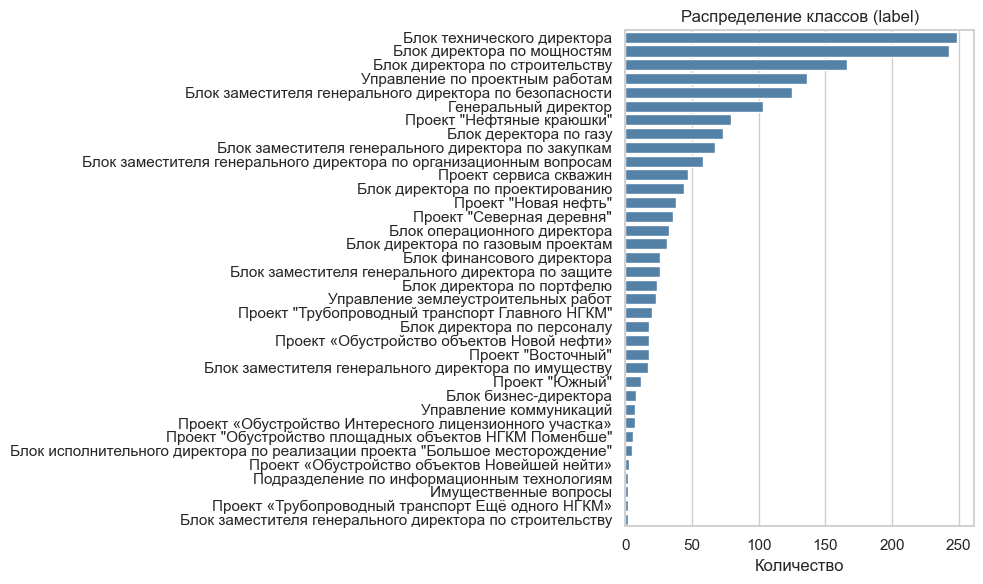

In [10]:
print("Классов:", label_counts.size)
print("min:", int(label_counts.min()), "max:", int(label_counts.max()))

# сколько классов имеют <= N примеров
for n in [5,10,20,50, 100, 150, 200, 240]:
    print(f"<= {n}: {(label_counts <= n).sum()} классов")

plt.figure(figsize=(10, 6))
sns.barplot(y=label_counts.index, x=label_counts.values, color="steelblue")
plt.title("Распределение классов (label)")
plt.xlabel("Количество")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [11]:
label_share = (label_counts / label_counts.sum())
p = label_share.values

entropy = -(p * np.log(p + 1e-12)).sum()
norm_entropy = entropy / np.log(len(p))
effective_classes = np.exp(entropy)         
gini = 1 - np.sum(p**2)  

print("Классов:", label_counts.size)
print("Энтропия:", round(entropy, 4))
print("Норм. энтропия (0..1):", round(norm_entropy, 4))
print("Эффективное число классов exp(H):", round(effective_classes, 2))
print("Gini (1 - sum p^2):", round(gini, 4))

Классов: 36
Энтропия: 2.9704
Норм. энтропия (0..1): 0.8289
Эффективное число классов exp(H): 19.5
Gini (1 - sum p^2): 0.9281


In [12]:
label_counts = df["label"].value_counts()
share = label_counts / label_counts.sum()
cum = share.cumsum()

for q in [0.80, 0.90, 0.95, 0.99]:
    k = int((cum <= q).sum() + 1)
    print(f"{int(q*100)}% данных покрывают топ-{k} классов")

80% данных покрывают топ-13 классов
90% данных покрывают топ-19 классов
95% данных покрывают топ-24 классов
99% данных покрывают топ-30 классов


In [13]:
tail_n = 15
print("Суммарно примеров в этих классах:", int(label_counts.tail(tail_n).sum()))
print("Доля датасета:", round(label_counts.tail(tail_n).sum()/len(df), 4))

Суммарно примеров в этих классах: 127
Доля датасета: 0.0716


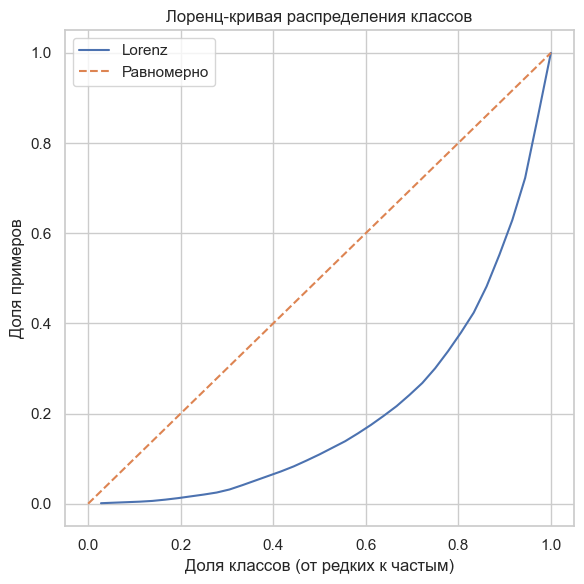

In [14]:
counts_sorted = label_counts.sort_values().values
cum_counts = np.cumsum(counts_sorted)
cum_share = cum_counts / cum_counts[-1]
x = np.arange(1, len(counts_sorted)+1) / len(counts_sorted)

plt.figure(figsize=(6,6))
plt.plot(x, cum_share, label="Lorenz")
plt.plot([0,1],[0,1], "--", label="Равномерно")
plt.title("Лоренц-кривая распределения классов")
plt.xlabel("Доля классов (от редких к частым)")
plt.ylabel("Доля примеров")
plt.legend()
plt.tight_layout()
plt.show()

В датасете **36 классов**, при этом распределение заметно неравномерное: размер класса варьируется от **2** до **249** примеров. Большая часть классов относится к “длинному хвосту”: **26 из 36** классов имеют **≤ 50** примеров, **30 из 36** — **≤ 100**, а **10 классов** имеют **≤ 10** примеров (из них **6 классов** — **≤ 5**). Это означает, что для значимой доли меток данных мало, и качество по этим классам будет нестабильным без дополнительных мер (веса классов, доразметка, объединение редких классов и т.п.).

По агрегированным метрикам дисбаланса распределение нельзя назвать “крайне перекошенным в один класс”, но оно существенно неравномерное. **Нормированная энтропия 0.8289** указывает на относительно высокое разнообразие классов, однако **эффективное число классов exp(H) ≈ 19.5** показывает, что по фактическому распределению данных задача ближе к классификации примерно на **~20 “равномерных” классов**, а оставшиеся классы вносят небольшой вклад и формируют хвост. Значение **Gini = 0.9281** также подтверждает, что масса не сосредоточена в одном-двух классах, но при этом не отменяет проблему редких классов.

Покрытие по кумулятивной доле дополнительно демонстрирует концентрацию данных в верхней части распределения: **80%** всех примеров дают **топ-13** классов, **90%** — **топ-19**, **95%** — **топ-24**, а чтобы покрыть **99%**, нужно уже **топ-30** классов. То есть последние ~6 классов дают суммарно около 1% данных.

Анализ “хвоста” (15 самых редких классов) показывает, что на них приходится **127 примеров**, то есть **~7.16%** датасета — это существенная доля, но размазанная по множеству малых классов. **Лоренц-кривая**, идущая “по дуге” ниже диагонали равномерности, визуально подтверждает неравномерность распределения: значимая часть примеров сосредоточена в относительно небольшом числе классов, а остальные классы представлены малым количеством наблюдений.

## Кластеризация

In [15]:
df2 = df[["text", "label"]].copy()
df2["text"] = df2["text"].astype(str).str.strip()
df2 = df2[df2["text"] != ""].reset_index(drop=True)

df2.shape, df2["label"].nunique()

((1774, 2), 36)

In [16]:
MAX_CHARS = 2000
df2["text_cut"] = df2["text"].str.slice(0, MAX_CHARS)

In [17]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

emb = model.encode(
    df2["text_cut"].tolist(),
    batch_size=64,
    show_progress_bar=False,
    normalize_embeddings=True
)

emb.shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

(1774, 384)

In [18]:
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)
xy = reducer.fit_transform(emb)
xy.shape

/Users/v.papadyk/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(1774, 2)

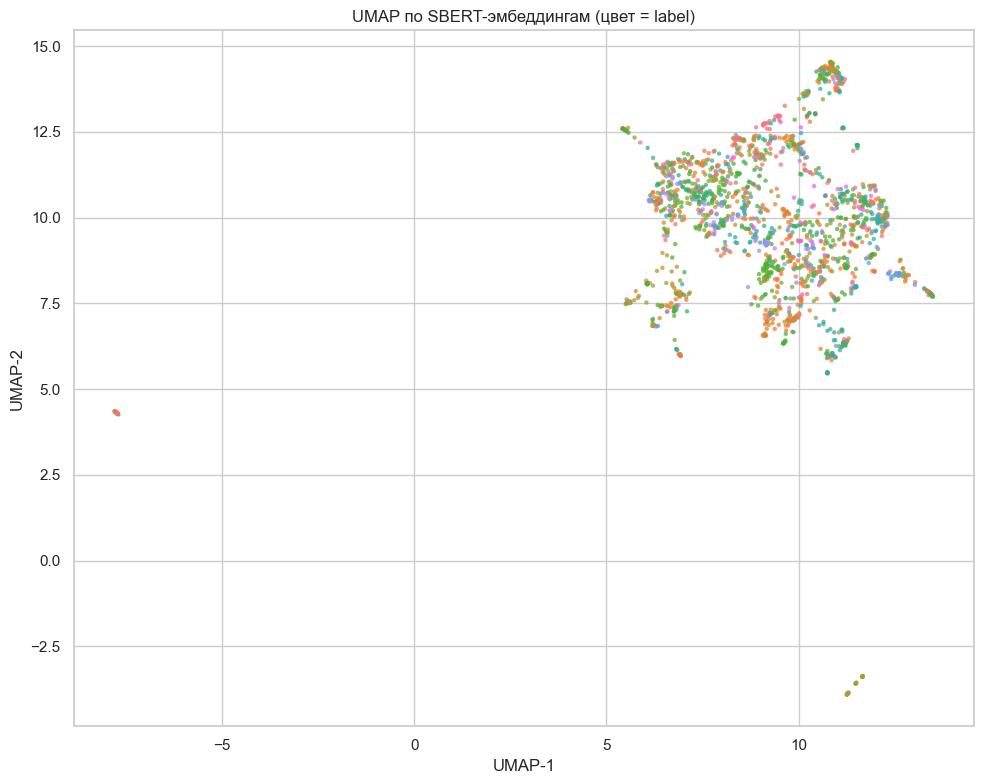

In [19]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=xy[:, 0], y=xy[:, 1],
    hue=df2["label"],
    s=10, alpha=0.75, linewidth=0,
    legend=False
)
plt.title("UMAP по SBERT-эмбеддингам (цвет = label)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

UMAP по SBERT-эмбеддингам — это способ сжать “смысловые” вектора текстов до 2D, чтобы глазами увидеть, есть ли в корпусе семантические группы. Выделим участок основного скопления точек:

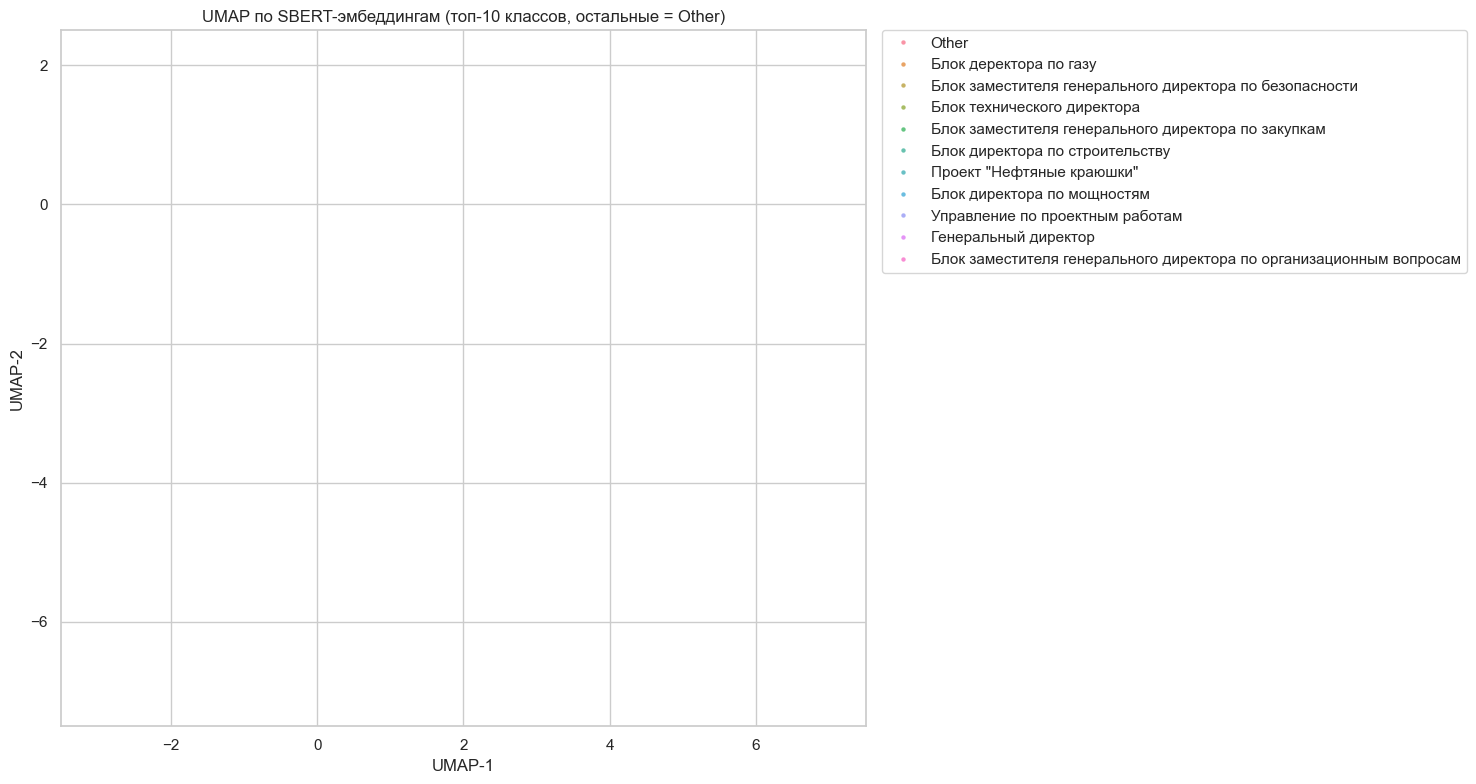

In [20]:
topN = 10
top_labels = df2["label"].value_counts().head(topN).index
df2["label_viz"] = np.where(df2["label"].isin(top_labels), df2["label"], "Other")

plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    x=xy[:, 0], y=xy[:, 1],
    hue=df2["label_viz"],
    s=10, alpha=0.75, linewidth=0,
    legend=True
)

ax.set_title(f"UMAP по SBERT-эмбеддингам (топ-{topN} классов, остальные = Other)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

ax.set_xlim(-3.5, 7.5)
ax.set_ylim(-7.5, 2.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

На картинке можно заметить острова розовых и голубых точек. Но они с враплениями других цветов. И эти же розовые и голобуые точки также хаотично распределены по всей остальной карте. Салотовые точки сгруппированы, но в разных частях карты.

Значит пвсе группы текстов, модель считает похожими по смыслу.
Эти классы семантически неотделимы: тексты внутри класса похожи между собой, но не сильно отличаются от других. Разные классы семантически близки. Будет не просто распознать классы.

Попробуем выделить семантические кластеры независимо от label, а потом посмотрим, какие label смешиваются в каждом кластере.

In [21]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean"
)

df2["cluster"] = clusterer.fit_predict(emb)

vc = df2["cluster"].value_counts()
display(vc.head(topN))

n_noise = int((df2["cluster"] == -1).sum())
print("Всего точек:", len(df2))
print("Шум (-1):", n_noise, f"({n_noise/len(df2):.1%})")
print("Кластеров (без шума):", int((vc.index != -1).sum()))

cluster
-1    1540
 2     106
 4      45
 3      34
 1      27
 0      22
Name: count, dtype: int64

Всего точек: 1774
Шум (-1): 1540 (86.8%)
Кластеров (без шума): 5


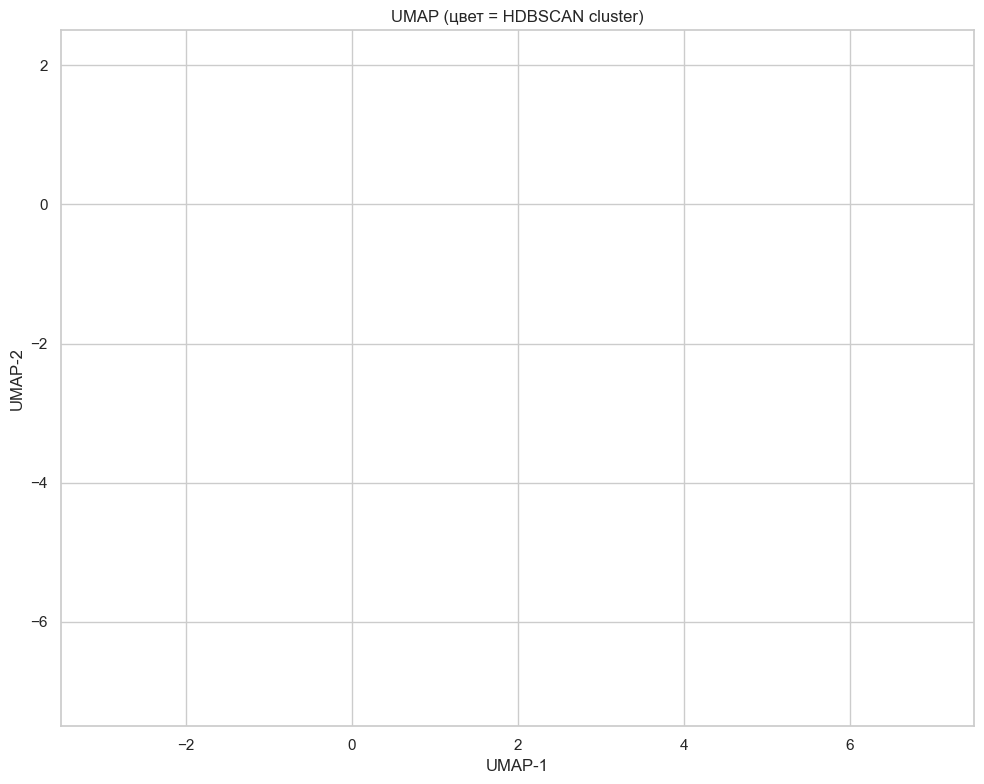

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=xy[:, 0], y=xy[:, 1],
    hue=df2["cluster"].astype(str),
    s=10, alpha=0.75, linewidth=0,
    legend=False
)
plt.title("UMAP (цвет = HDBSCAN cluster)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")

plt.xlim(-3.5, 7.5)
plt.ylim(-7.5, 2.5)

plt.tight_layout()
plt.show()

Шум 86.8% (1540 из 1774): HDBSCAN считает, что для большинства документов нет достаточно плотных, устойчивых групп при текущих параметрах.
То есть “семантические острова” либо маленькие/разреженные, либо переходят друг в друга.

Нашлось 5 кластеров (22–106 документов): это, скорее всего, самые плотные и шаблонные подмножества корпуса.

Главная ценность сейчас — понять, что это за 5 кластеров и какие label в них смешаны.

In [23]:
cluster_label = (
    df2[df2["cluster"] != -1]
    .groupby(["cluster", "label"])
    .size()
    .reset_index(name="n")
)

top_in_cluster = (cluster_label
                  .sort_values(["cluster", "n"], ascending=[True, False])
                  .groupby("cluster")
                  .head(10))

top_in_cluster

,cluster,label,n
4,0,Управление по проектным работам,13
0,0,Блок директора по мощностям,4
3,0,Проект сервиса скважин,3
1,0,Блок директора по строительству,1
2,0,Блок технического директора,1
7,1,"Проект ""Трубопроводный транспорт Главного НГКМ""",10
5,1,Блок директора по строительству,7
8,1,Проект «Обустройство объектов Новой нефти»,7
6,1,Блок технического директора,3
11,2,Блок директора по строительству,49


По этой таблице видно, что HDBSCAN действительно нашёл **семантические группы**, но они **не совпадают с label**: каждый кластер — это смесь нескольких классов. Это хорошо согласуется с интерпретацией UMAP.

1) Кластер 2 (n=106) — самый большой “остров”
Состав:
- Блок директора по строительству — 49
- Блок технического директора — 31
- дальше мелкие примеси (по 1–6)

Интерпретация:
- Это **устойчивая семантическая группа**, которая объединяет тексты из разных “блоков”.
- модель будет видеть очень похожие тексты, но с разными метками → будет путаться.
- Вероятнее всего, это один тип документа/шаблон (например, служебные письма/согласования/приказы по стройке/технике), который встречается у разных адресатов/подразделений.

2) Кластер 4 (n=45) — “Генеральный директор” как стиль/шаблон
Состав:
- Генеральный директор — 26 (доминирует)
- дальше: портфель (4), газ (3), проектные работы (3), и т.д.

Интерпретация:
- Похоже на группу документов, где **явно присутствует атрибутика/формулировки уровня ГД** (подпись, шапка, обращения), но часть таких же по форме документов размечена другими label.
- Возможны два объяснения:
  1) **семантика текста** действительно “про ГД” (приказы/распоряжения),
  2) или это **шаблон документа**, который иногда уходит в другие классы из‑за разметки.

3) Кластер 0 (n=22) — “Управление по проектным работам”
Состав:
- Управление по проектным работам — 13
- остальное по 1–4

Интерпретация:
- Небольшая, но относительно “чистая” группа. Вероятно, специфический тип документов/лексика проектных работ.

4) Кластер 1 (n=27) — проект “Трубопроводный транспорт…”
Состав:
- Проект "Трубопроводный транспорт Главного НГКМ" — 10
- Блок директора по строительству — 7
- Проект «Обустройство объектов Новой нефти» — 7
- + немного техдир

Интерпретация:
- Это выглядит как **кластер “проектных документов”** (возможно, похожие отчёты/письма по проектам), где разные проектные label и “строительство” смешались в один семантический тип.

5) Кластер 3 (n=34) — смешанный “проектно-технический”
Состав:
- Проект "Восточный" — 7
- Блок технического директора — 5
- Газовые проекты — 4
- Строительство — 3
- и т.д.

Интерпретация:
- Похоже на ещё одну “тему/тип документа”, общую для нескольких направлений.

---

Главный вывод по кластеризации

HDBSCAN подтверждает: **семантические группы в корпусе есть**, но они в основном отражают **тип/шаблон документа или общую тематику**, а не организационную метку `label`. Поэтому:
- классы **семантически неотделимы** чисто по тексту в ряде зон,
- часть разметки может быть **взаимозаменяемой/конфликтной** (одинаковые по смыслу тексты размечены разными label).

In [24]:
def show_cluster_centroid(c, n=7):
    idx = df2.index[df2["cluster"] == c].to_numpy()
    E = emb[idx]
    centroid = E.mean(axis=0, keepdims=True)
    sim = (E @ centroid.T).ravel()  # emb нормализованы => это cos sim
    top_local = np.argsort(-sim)[:n]
    top_idx = idx[top_local]
    display(df2.loc[top_idx, ["cluster", "label", "text"]])

for c in sorted(df2["cluster"].unique()):
    if c == -1:
        continue
    print(f"\n=== cluster {c} ===")
    show_cluster_centroid(c, n=7)


=== cluster 0 ===


,cluster,label,text
46,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[ID] От [DATE_TIME]г. На От О заключении ...
284,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На [DOCUMENT_NUMBER] - О закл...
409,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На [DOCUMENT_NUMBER] - О закл...
655,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На [DOCUMENT_NUMBER]/[DATE_TI...
803,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На От [PERSON] управления по ...
506,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На [DOCUMENT_NUMBER] От [DATE...
657,0,Управление по проектным работам,[ORGANIZATION] АКЦИОНЕРНОЕ ОБЩЕСТВО Но [DOCUMENT_NUMBER]-[DOCUMENT_NUMBER]-[DATE_TIME] На От [DOCUMENT_NUMBER]/[DATE...



=== cluster 1 ===


,cluster,label,text
25,1,"Проект ""Трубопроводный транспорт Главного НГКМ""","[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
1541,1,"Проект ""Трубопроводный транспорт Главного НГКМ""","[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
1166,1,Проект «Обустройство объектов Новой нефти»,"[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
521,1,Блок директора по строительству,"[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
1727,1,"Проект ""Трубопроводный транспорт Главного НГКМ""","[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
26,1,Проект «Обустройство объектов Новой нефти»,"[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."
1420,1,"Проект ""Трубопроводный транспорт Главного НГКМ""","[ORGANIZATION] Адрес местонахождения: [LOCATION] Тел.: [CONTACT], e-mail: [CONTACT] Адрес местонахождения Обособленн..."



=== cluster 2 ===


,cluster,label,text
904,2,Блок технического директора,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
325,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
361,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
362,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
363,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
828,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."
433,2,Блок директора по строительству,"[ORGANIZATION] Юридический адрес: [LOCATION] Почтовый адрес: [LOCATION] тел., факс: [CONTACT] приемная тел.: [CONTAC..."



=== cluster 3 ===


,cluster,label,text
1699,3,"Проект ""Восточный""","[ORGANIZATION] [LOCATION] Тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[DOMAIN] ОКПО [ID], ОГРН [DOCUMENT_..."
1612,3,Блок директора по газовым проектам,"[ORGANIZATION] [LOCATION] Тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[DOMAIN] ОКПО [ID], ОГРН [DOCUMENT_..."
496,3,Блок технического директора,"[ORGANIZATION] [LOCATION] тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[ORGANIZATION] ОКПО [ID], ОГРН [DOC..."
1335,3,Блок операционного директора,"[ORGANIZATION] [LOCATION] тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[ORGANIZATION] ОКПО [ID], ОГРН [DOC..."
1570,3,"Проект ""Восточный""","[ORGANIZATION] [LOCATION] Тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[ORGANIZATION] ОКПО [ID], ОГРН [DOC..."
92,3,"Блок исполнительного директора по реализации проекта ""Большое месторождение""","[ORGANIZATION] [LOCATION] Тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[DOMAIN] ОКПО [ID], ОГРН [DOCUMENT_..."
1235,3,Блок директора по газовым проектам,"[ORGANIZATION] [LOCATION] Тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[DOMAIN] ОКПО [ID], ОГРН [DOCUMENT_..."



=== cluster 4 ===


,cluster,label,text
1593,4,Блок деректора по газу,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: [L...
1161,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: [L...
1725,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: [L...
1609,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: [L...
1455,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: [L...
1592,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: БО...
1010,4,Генеральный директор,[ORGANIZATION] Публичное акционерное общество [ORGANIZATION] ([ORGANIZATION]) Адрес для почтовой корреспонденции: БО...


## Анализ текста

In [25]:
dup_mask = df2.duplicated(subset=["text"], keep=False)
print("Доля строк с повторяющимся text:", round(dup_mask.mean(), 4))

Доля строк с повторяющимся text: 0.0056


In [26]:
def simple_tokens(s: str):
    s = "" if pd.isna(s) else str(s).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.split() if s else []

df2["n_chars"] = df2["text"].astype(str).str.len()
df2["n_words"] = df2["text"].astype(str).str.split().map(len)
df2["tokens"] = df2["text"].map(simple_tokens)
df2["n_tokens"] = df2["tokens"].map(len)

df2[["n_chars","n_words","n_tokens"]].describe(percentiles=[.5,.75,.9,.95,.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_chars,1774.0,2923.601466,7091.163226,49.0,1277.5,1921.50,3590.6,6843.70,44951.03,69225.0
n_words,1774.0,315.519729,701.418785,8.0,149.0,230.00,424.7,846.75,4697.51,7455.0
n_tokens,1774.0,318.881060,689.874357,6.0,152.5,232.75,439.0,856.10,4344.82,7456.0


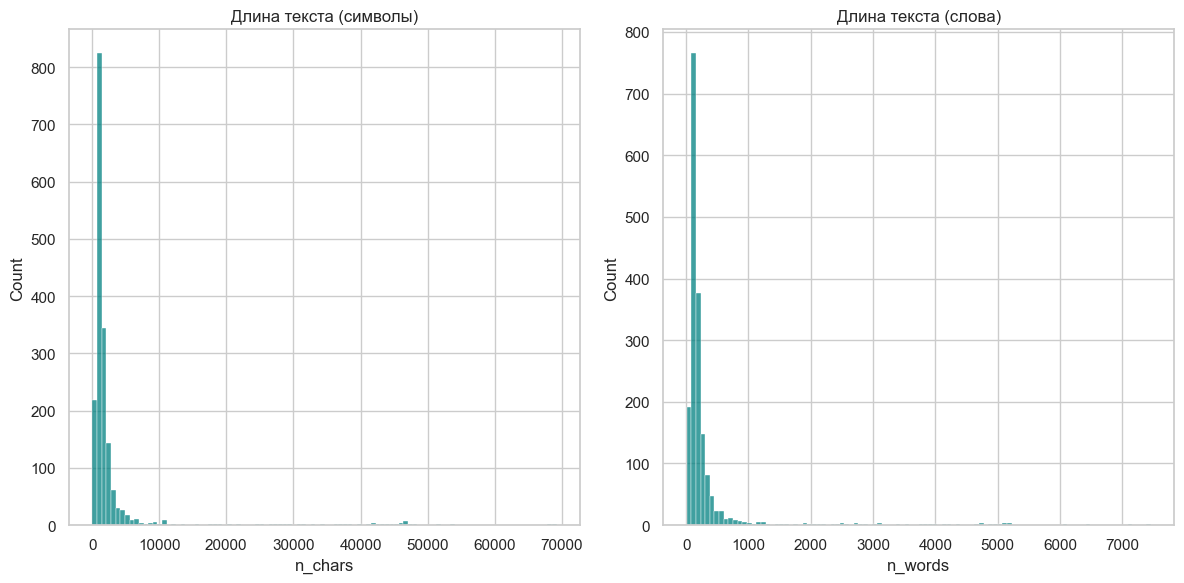

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df2["n_chars"], bins=100, ax=axes[0], color="teal")
axes[0].set_title("Длина текста (символы)")

sns.histplot(df2["n_words"], bins=100, ax=axes[1], color="teal")
axes[1].set_title("Длина текста (слова)")

plt.tight_layout()
plt.show()

In [28]:
def top_bigrams(mask, k=20):
    c = Counter()
    for toks in df2.loc[mask, "tokens"]:
        for a, b in zip(toks, toks[1:]):
            c[(a, b)] += 1
    return c.most_common(k)

for c in sorted(df2["cluster"].unique()):
    if c == -1:
        continue
    mask = df2["cluster"] == c
    print(f"\n=== cluster {c} bigrams ===")
    print(top_bigrams(mask, k=15))


=== cluster 0 bigrams ===
[(('от', 'date_time'), 60), (('no', 'document_number'), 59), (('document_number', 'от'), 43), (('тел', 'contact'), 34), (('управления', 'по'), 26), (('date_time', 'г'), 25), (('document_number', 'document_number'), 24), (('уважаемый', 'person'), 22), (('к', 'договору'), 21), (('organization', 'person'), 21), (('руб', 'financial_data'), 20), (('person', 'contact'), 19), (('document_number', 'date_time'), 17), (('с', 'уважением'), 16), (('contact', 'факс'), 16)]

=== cluster 1 bigrams ===
[(('financial_data', 'financial_data'), 6105), (('наименование', 'наименование'), 2863), (('наименование', 'поставщика'), 884), (('поставщика', 'адресная'), 883), (('адресная', 'наименование'), 882), (('руб', 'стоимость'), 743), (('стоимость', 'услуг'), 743), (('услуг', 'руб'), 742), (('document_number', 'financial_data'), 668), (('по', 'document_number'), 668), (('financial_data', 'по'), 667), (('объекты', 'объекты'), 574), (('стоимость', 'руб'), 202), (('кг', 'норма'), 201),

По биграммам видно, что HDBSCAN кластеры в значительной степени образуются **не по “теме”**, а по **формату/шаблону документа** и по наличию **маскированных сущностей** (`[FINANCIAL_DATA]`, `[DOCUMENT_NUMBER]`, `[DATE_TIME]`, `[PERSON]`, `[CONTACT]` и т.п.). Это очень важный вывод: SBERT “видит” повторяющиеся паттерны и группирует их.

Ниже — интерпретация каждого кластера и что можно улучшить.

### Интерпретация кластеров по биграммам

#### Cluster 0
Топ биграммы: `('от','date_time')`, `('no','document_number')`, `('тел','contact')`, `('уважаемый','person')`, `('с','уважением')`, `('к','договору')`, `('руб','financial_data')`.

Похоже на **письма/сопроводительные/договорная переписка**: есть обращения, контакты, “с уважением”, реквизиты, даты/номера.

#### Cluster 1
Очень сильные повторы: `('financial_data','financial_data')`, `('наименование','наименование')`, `('наименование','поставщика')`, `('стоимость','услуг')`, `('руб','стоимость')`, `('кг','норма')`.

Это выглядит как **табличные/реестровые документы** (сметы, спецификации, заявки/закупки, перечни услуг/материалов), где много денег/стоимостей/наименований.  
Гигантские счётчики (тысячи) намекают, что тексты либо **очень длинные**, либо содержат **повторяющиеся колонки/ячейки**, либо есть много почти одинаковых документов.

#### Cluster 2
Топ: `('financial_data','financial_data')`, `('приказы','приказы')`, `('document_number','document_number')`, `('номер','документа')`, `('наименование','подразделения')`, `('person','position')`, `('position','group')`, `('от','date_time')`.

Похоже на **выгрузки/реестры приказов/документов** или документы с большим количеством перечислений “номер документа / подразделение / должность / группа”. Опять же — формат/шаблон.

#### Cluster 3
Топ: `('no','document_number')`, `('date_time','no')`, `('e','mail')`, `('тел','contact')`, `('факс','contact')`, `('organization','location')`, `('окпо','id')`, `('уважаемый','person')`.

Это очень похоже на **официальные письма/бланки организаций** с реквизитами (адрес, ОКПО, телефон/факс/email).

#### Cluster 4
Топ: `('person','person')` (очень много), плюс `('no','document_number')`, `('от','date_time')`, `('organization','person')`, `('пао','organization')`, `('адрес','для')`, контакты.

Похоже на документы, где много **ФИО/упоминаний персон** (возможно, списки согласующих/адресатов/подписантов) + реквизиты. То, что `('person','person')` доминирует, говорит: модель группирует тексты по “насыщенности персонами”.

---

### Главный вывод
Ваши “семантические группы” сейчас — это в основном **группы по структуре документа и типу контента (реквизиты/таблицы/финансы/приказы/контакты)**, а не по организационным `label`. Поэтому:
- кластеры смешивают разные label (что вы и видите),
- и классификация “по блокам” по одному тексту действительно может быть сложной.

---

### Что можно сделать, чтобы искать именно “смысловые” группы (а не формат)
Если цель — найти группы по теме, попробуйте один из вариантов предобработки перед эмбеддингами:

Удалить/схлопнуть маски сущностей
Сейчас токены типа `financial_data`, `document_number`, `date_time`, `contact`, `id`, `person` сильно влияют.



In [29]:
def drop_placeholders(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    # если у вас плейсхолдеры в виде [FINANCIAL_DATA] и т.п.
    s = re.sub(r"\[(FINANCIAL_DATA|DOCUMENT_NUMBER|DATE_TIME|CONTACT|ID|PERSON|ORGANIZATION|LOCATION|PRODUCT)\]", " ", s, flags=re.I)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df2["text_sem"] = df2["text"].map(drop_placeholders).str.slice(0, MAX_CHARS)

In [30]:
emb = model.encode(
    df2["text_sem"].tolist(),
    batch_size=64,
    show_progress_bar=False,
    normalize_embeddings=True
)

In [31]:
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)
xy = reducer.fit_transform(emb)

/Users/v.papadyk/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


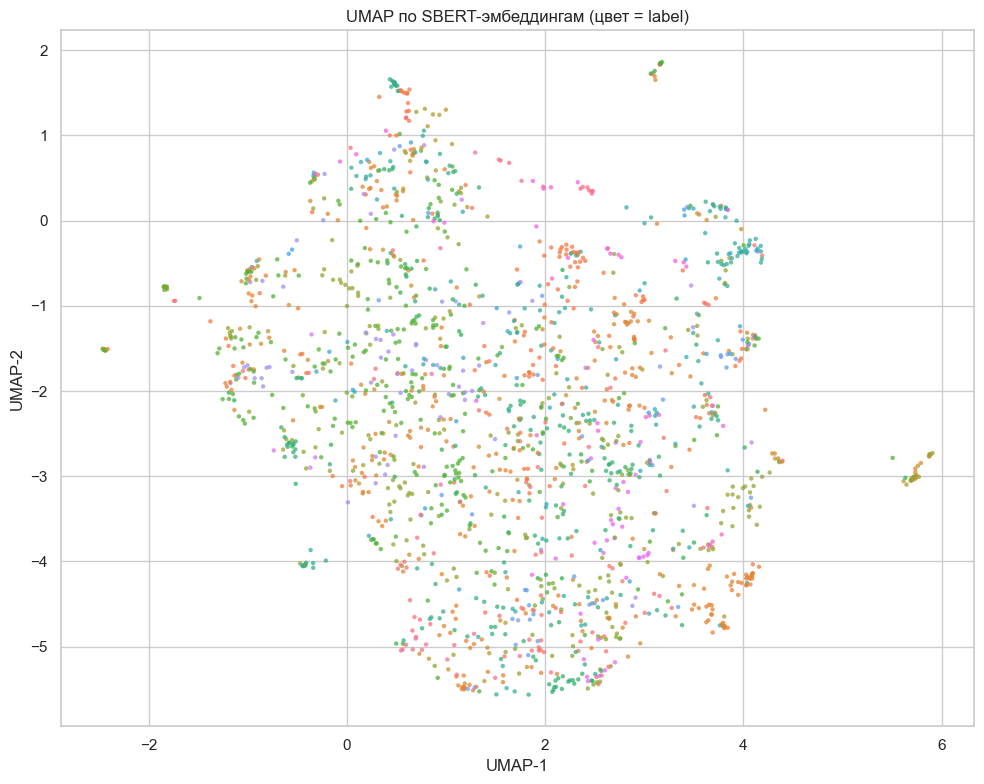

In [32]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=xy[:, 0], y=xy[:, 1],
    hue=df2["label"],
    s=10, alpha=0.75, linewidth=0,
    legend=False
)
plt.title("UMAP по SBERT-эмбеддингам (цвет = label)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

Выбросы исчезли, но группы по-прежнему не образуют четких островов.

In [33]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean"
)

df2["cluster"] = clusterer.fit_predict(emb)

vc = df2["cluster"].value_counts()
display(vc.head(topN))

n_noise = int((df2["cluster"] == -1).sum())
print("Всего точек:", len(df2))
print("Шум (-1):", n_noise, f"({n_noise/len(df2):.1%})")
print("Кластеров (без шума):", int((vc.index != -1).sum()))

cluster
-1    1626
 2      44
 0      42
 3      40
 1      22
Name: count, dtype: int64

Всего точек: 1774
Шум (-1): 1626 (91.7%)
Кластеров (без шума): 4


Шума стало, только больше, а число кластеров уменьшилось.

# Очистка дубликатов и шума

In [34]:
path = Path("../data/cleaned_df.csv")

df_clean = pd.read_csv(path)

In [36]:
df_clean.iloc[1720]["text"]

'[ORGANIZATION] НЕФТЬ Публичное акционерное общество [ORGANIZATION] Руководителям дочерних обществ и совместных предприятий [ORGANIZATION] Для корреспонденции: [LOCATION] ОКПО [ID], ОГРН [ID], ИНН [ID], КПП [ID] [DATE_TIME] г. No [DOCUMENT_NUMBER] на No** от _ О направлении решения по результатам учебно-методического сбора Уважаемые руководители! Для информации и использования в работе направляю решение по результатам учебно-методического сбора с руководителями постоянно действующих органов управления системы гражданской защиты [ORGANIZATION] по подведению итогов деятельности системы гражданской защиты в [DATE_TIME] году и постановке задач на [DATE_TIME] год. Ходатайствую о поощрении работников, отмеченных в лучшую сторону по результатам деятельности в области гражданской обороны и защиты от чрезвычайных ситуаций в [DATE_TIME] году. Просьба довести решение до сведения подчиненных дочерних обществ и совместных предприятий. [ATTACHMENTS]'

In [37]:
dup_mask = df_clean.duplicated(subset=["text"], keep=False)
print("Доля строк с повторяющимся text:", round(dup_mask.mean(), 4))

Доля строк с повторяющимся text: 0.0091


In [39]:
def simple_tokens(s: str):
    s = "" if pd.isna(s) else str(s).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.split() if s else []

df_clean["n_chars"] = df_clean["text"].astype(str).str.len()
df_clean["n_words"] = df_clean["text"].astype(str).str.split().map(len)
df_clean["tokens"] = df_clean["text"].map(simple_tokens)
df_clean["n_tokens"] = df_clean["tokens"].map(len)

df_clean[["n_chars","n_words","n_tokens"]].describe(percentiles=[.5,.75,.9,.95,.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_chars,1755.0,1238.305413,1086.087630,49.0,964.0,1405.0,2128.6,2733.2,5961.76,16334.0
n_words,1755.0,144.763533,129.203496,8.0,111.0,166.5,247.6,328.3,723.76,1864.0
n_tokens,1755.0,148.276353,130.882094,6.0,115.0,171.0,249.6,330.6,742.98,1897.0


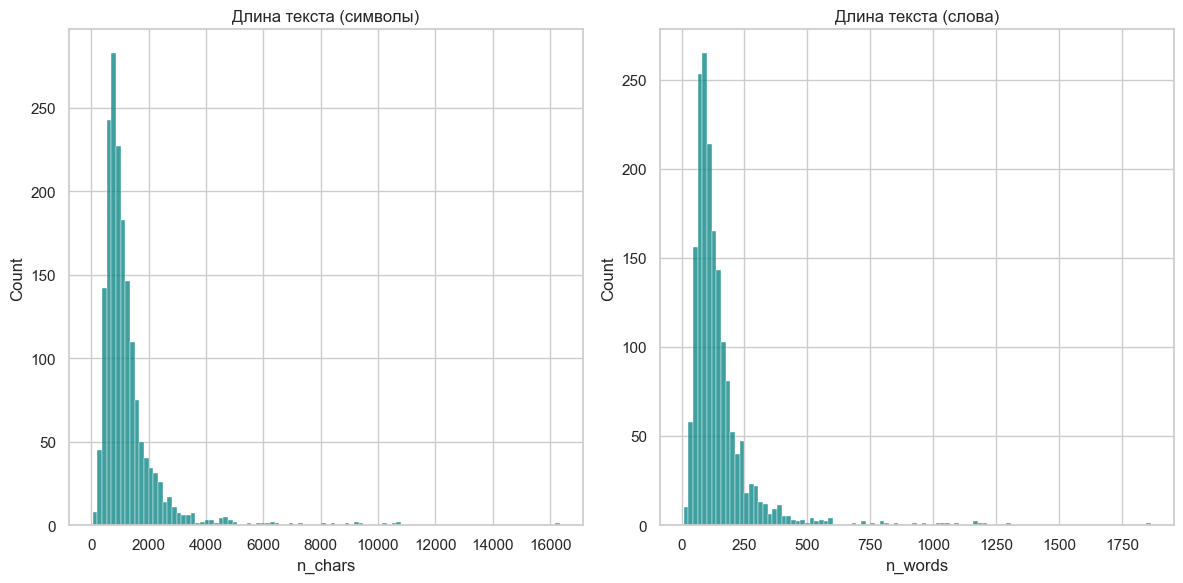

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df_clean["n_chars"], bins=100, ax=axes[0], color="teal")
axes[0].set_title("Длина текста (символы)")

sns.histplot(df_clean["n_words"], bins=100, ax=axes[1], color="teal")
axes[1].set_title("Длина текста (слова)")

plt.tight_layout()
plt.show()